In [ ]:
from google.colab import files

uploaded = files.upload()


Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


In [ ]:
import pandas as pd

fear = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Fear & Greed Dataset")
print(fear.head())
print("\nColumns:")
print(fear.columns)

print("\n" + "="*50 + "\n")

print("Historical Trading Dataset")
print(trades.head())
print("\nColumns:")
print(trades.columns)

Fear & Greed Dataset
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


Historical Trading Dataset
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       

In [ ]:
import pandas as pd

fear = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

# Convert dates
fear['date'] = pd.to_datetime(fear['date'])

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

trades['date'] = trades['Timestamp IST'].dt.date
fear['date_only'] = fear['date'].dt.date


In [ ]:
merged = trades.merge(
    fear[['date_only','classification','value']],
    left_on='date',
    right_on='date_only',
    how='left'
)

print("Merged Shape:", merged.shape)
print(merged[['classification','Closed PnL']].head())

Merged Shape: (211224, 20)
  classification  Closed PnL
0  Extreme Greed         0.0
1  Extreme Greed         0.0
2  Extreme Greed         0.0
3  Extreme Greed         0.0
4  Extreme Greed         0.0


In [ ]:
profit_stats = merged.groupby('classification')['Closed PnL'].agg([
    'count',
    'mean',
    'median',
    'sum'
])

print(profit_stats)


                count       mean  median           sum
classification                                        
Extreme Fear    21400  34.537862     0.0  7.391102e+05
Extreme Greed   39992  67.892861     0.0  2.715171e+06
Fear            61837  54.290400     0.0  3.357155e+06
Greed           50303  42.743559     0.0  2.150129e+06
Neutral         37686  34.307718     0.0  1.292921e+06


In [ ]:
merged['Win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby(
    'classification'
)['Win'].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


In [ ]:
volume = merged.groupby(
    'classification'
)['Size USD'].sum()

print(volume)


classification
Extreme Fear     1.144843e+08
Extreme Greed    1.244652e+08
Fear             4.833248e+08
Greed            2.885825e+08
Neutral          1.802421e+08
Name: Size USD, dtype: float64


In [ ]:
side_analysis = pd.crosstab(
    merged['classification'],
    merged['Side']
)

print(side_analysis)


Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


In [ ]:
fees = merged.groupby(
    'classification'
)['Fee'].mean()

print(fees)

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64


In [ ]:
top_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


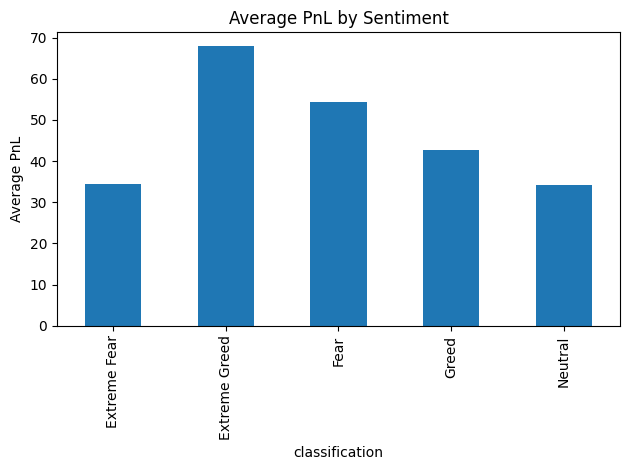

In [ ]:
import matplotlib.pyplot as plt

# Average PnL
merged.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title('Average PnL by Sentiment')
plt.ylabel('Average PnL')
plt.tight_layout()
plt.savefig('avg_pnl.png')
plt.show()

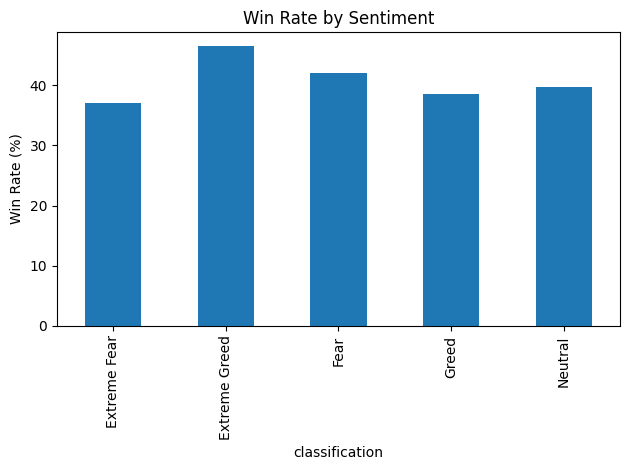

In [ ]:
# Win Rate
(merged.groupby('classification')['Win'].mean()*100).plot(kind='bar')
plt.title('Win Rate by Sentiment')
plt.ylabel('Win Rate (%)')
plt.tight_layout()
plt.savefig('win_rate.png')
plt.show()

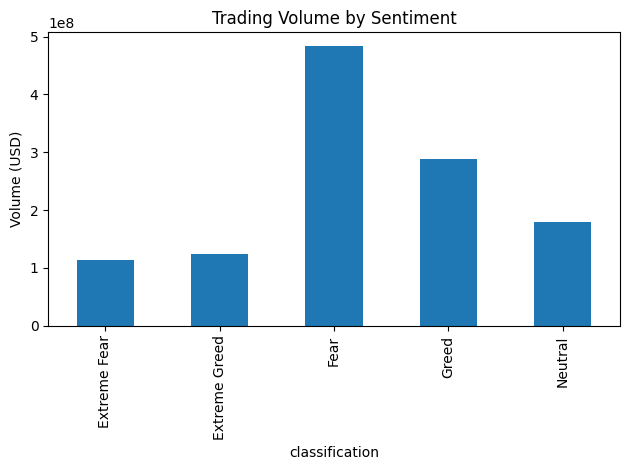

In [ ]:
# Trading Volume
merged.groupby('classification')['Size USD'].sum().plot(kind='bar')
plt.title('Trading Volume by Sentiment')
plt.ylabel('Volume (USD)')
plt.tight_layout()
plt.savefig('volume.png')
plt.show()